# Notebook 5 — Genetic Algorithm Feature Selection

## Why this notebook exists

We currently have many features (after one-hot encoding). Some help prediction;
some add noise. A **Genetic Algorithm (GA)** searches for a good subset.

This is a nature-inspired method based on evolution:

| Biology idea | Our code idea |
|---|---|
| Chromosome / DNA | A list of 0s and 1s (one bit per feature) |
| Fitness | How good that feature subset is |
| Selection | Prefer better chromosomes as parents |
| Crossover | Combine two parents into children |
| Mutation | Randomly flip bits to keep exploring |
| Elitism | Always keep the best individuals |

| | |
|---|---|
| **Input** | `data/clean/X_train.csv`, `y_train.csv` |
| **Output** | selected feature list, GA result JSON, fitness chart |
| **Why it is needed** | Course core: GA for feature selection; winner later feeds TabNet. |
## Why we use GA instead of PCA

PCA compresses features into anonymous components. That can shrink
dimension, but the new axes are hard to explain to a business team
("component 3" is not a retention lever).

GA keeps **named original features**, searches for a smaller useful
subset, and stays viva-friendly. With ~33 columns after encoding, feature
selection is enough — **PCA is not required** for this project.


## Fitness function (what “good” means)

For one chromosome (feature mask):

1. Keep only features where the bit is `1`
2. Train a small Random Forest with **3-fold stratified cross-validation**
3. Measure average **F1**
4. Subtract a small penalty if too many features are selected

\[
\text{fitness} = \text{CV F1} - \lambda \times \frac{\text{selected features}}{\text{total features}}
\]

With \(\lambda = 0.05\). This pushes the GA toward smaller subsets when F1 is similar.

In [1]:
import os
import json
import random
import time

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

CLEAN_FOLDER = "../data/clean"
FIGURE_FOLDER = "../figures"
os.makedirs(FIGURE_FOLDER, exist_ok=True)

X_train = pd.read_csv(CLEAN_FOLDER + "/X_train.csv")
y_train = pd.read_csv(CLEAN_FOLDER + "/y_train.csv")["Churn"].tolist()

feature_names = list(X_train.columns)
X_values = X_train.values
n_features = len(feature_names)

print("Number of features:", n_features)
print("Training rows:", len(y_train))

Number of features: 33
Training rows: 4504


## Step 1 — GA settings and helper functions

These numbers are intentionally small so the notebook finishes in a reasonable
time, while still showing real evolutionary improvement.

In [2]:
POP_SIZE = 20
N_GENERATIONS = 25
CROSSOVER_RATE = 0.8
MUTATION_RATE = 0.05
TOURNAMENT_K = 3
ELITE = 2
LAMBDA_SPARSITY = 0.05
CV_SPLITS = 3


def make_random_forest():
    """Small RF used only to score a feature subset."""
    return RandomForestClassifier(
        n_estimators=60,
        max_depth=6,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )


def count_selected(mask):
    """Count how many 1s are in the chromosome."""
    total = 0
    for bit in mask:
        if bit == 1:
            total = total + 1
    return total


def fitness(mask):
    """
    Score one chromosome.
    mask is a list of 0/1 values, one per feature.
    """
    selected_count = count_selected(mask)
    if selected_count == 0:
        return 0.0

    # Build a list of column positions where bit == 1
    selected_positions = []
    for i in range(n_features):
        if mask[i] == 1:
            selected_positions.append(i)

    X_subset = X_values[:, selected_positions]

    cv = StratifiedKFold(
        n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_SEED
    )
    scores = cross_val_score(
        make_random_forest(),
        X_subset,
        y_train,
        cv=cv,
        scoring="f1",
    )

    mean_f1 = float(scores.mean())
    penalty = LAMBDA_SPARSITY * (selected_count / n_features)
    return mean_f1 - penalty


def create_random_chromosome():
    """Create one random 0/1 list. Guarantee at least one feature is on."""
    chromosome = []
    for i in range(n_features):
        chromosome.append(random.randint(0, 1))

    if count_selected(chromosome) == 0:
        chromosome[random.randint(0, n_features - 1)] = 1
    return chromosome


def init_population():
    """Create POP_SIZE random chromosomes."""
    population = []
    for i in range(POP_SIZE):
        population.append(create_random_chromosome())
    return population


print("Helper functions ready.")
print("Population size:", POP_SIZE)
print("Generations:", N_GENERATIONS)

Helper functions ready.
Population size: 20
Generations: 25


## Step 2 — Selection, crossover, mutation

- **Tournament selection:** pick `TOURNAMENT_K` random individuals; the best
  of those becomes a parent.
- **Single-point crossover:** cut two parents at one random point and swap tails.
- **Bit-flip mutation:** each bit flips with probability `MUTATION_RATE`.

In [3]:
def tournament_select(population, fitness_scores):
    """Pick the best among TOURNAMENT_K random candidates."""
    best_index = None
    best_fit = -1e9

    for t in range(TOURNAMENT_K):
        index = random.randint(0, len(population) - 1)
        if fitness_scores[index] > best_fit:
            best_fit = fitness_scores[index]
            best_index = index

    # Return a copy so later mutation does not change the parent in-place
    selected = []
    for bit in population[best_index]:
        selected.append(bit)
    return selected


def crossover(parent1, parent2):
    """Single-point crossover. Sometimes returns copies of the parents."""
    if random.random() > CROSSOVER_RATE:
        child1 = []
        child2 = []
        for bit in parent1:
            child1.append(bit)
        for bit in parent2:
            child2.append(bit)
        return child1, child2

    point = random.randint(1, n_features - 1)

    child1 = []
    child2 = []
    for i in range(n_features):
        if i < point:
            child1.append(parent1[i])
            child2.append(parent2[i])
        else:
            child1.append(parent2[i])
            child2.append(parent1[i])
    return child1, child2


def mutate(chromosome):
    """Flip bits randomly. Guarantee at least one feature stays selected."""
    mutated = []
    for bit in chromosome:
        if random.random() < MUTATION_RATE:
            # Flip 0 -> 1 or 1 -> 0
            if bit == 0:
                mutated.append(1)
            else:
                mutated.append(0)
        else:
            mutated.append(bit)

    if count_selected(mutated) == 0:
        mutated[random.randint(0, n_features - 1)] = 1
    return mutated


print("Selection / crossover / mutation ready.")

Selection / crossover / mutation ready.


## Step 3 — Run the Genetic Algorithm

Each generation:

1. Score every chromosome
2. Remember the global best
3. Keep the top `ELITE` chromosomes
4. Fill the rest of the next population with children from crossover + mutation

This cell takes a few minutes because each fitness call trains a Random Forest
several times.

In [4]:
start_time = time.time()

population = init_population()
best_fitness_history = []
mean_fitness_history = []

best_chromosome = None
best_fitness = -1e9

for generation in range(N_GENERATIONS):
    fitness_scores = []
    for individual in population:
        fitness_scores.append(fitness(individual))

    # Find best in this generation
    gen_best_index = 0
    for i in range(1, len(fitness_scores)):
        if fitness_scores[i] > fitness_scores[gen_best_index]:
            gen_best_index = i

    gen_best_fit = fitness_scores[gen_best_index]
    gen_best_chrom = population[gen_best_index]

    if gen_best_fit > best_fitness:
        best_fitness = gen_best_fit
        best_chromosome = []
        for bit in gen_best_chrom:
            best_chromosome.append(bit)

    # Mean fitness of the generation
    total_fit = 0.0
    for value in fitness_scores:
        total_fit = total_fit + value
    mean_fit = total_fit / len(fitness_scores)

    best_fitness_history.append(gen_best_fit)
    mean_fitness_history.append(mean_fit)

    print(
        "Gen", generation,
        "| best =", round(gen_best_fit, 4),
        "| mean =", round(mean_fit, 4),
        "| bits =", count_selected(gen_best_chrom),
    )

    # --- Build next generation ---
    # Elitism: copy the top ELITE chromosomes
    indexed_scores = []
    for i in range(len(fitness_scores)):
        indexed_scores.append([fitness_scores[i], i])
    indexed_scores.sort(reverse=True)  # highest fitness first

    new_population = []
    for e in range(ELITE):
        elite_index = indexed_scores[e][1]
        elite_copy = []
        for bit in population[elite_index]:
            elite_copy.append(bit)
        new_population.append(elite_copy)

    # Fill the rest with children
    while len(new_population) < POP_SIZE:
        parent1 = tournament_select(population, fitness_scores)
        parent2 = tournament_select(population, fitness_scores)
        child1, child2 = crossover(parent1, parent2)
        new_population.append(mutate(child1))
        if len(new_population) < POP_SIZE:
            new_population.append(mutate(child2))

    population = new_population

ga_seconds = time.time() - start_time
print()
print("GA finished in", round(ga_seconds, 1), "seconds")
print("Best fitness:", round(best_fitness, 4))
print("Features selected:", count_selected(best_chromosome), "/", n_features)

Gen 0 | best = 0.6188 | mean = 0.5562 | bits = 12


Gen 1 | best = 0.6296 | mean = 0.5839 | bits = 15


Gen 2 | best = 0.632 | mean = 0.6035 | bits = 16


Gen 3 | best = 0.6433 | mean = 0.6092 | bits = 16


Gen 4 | best = 0.6433 | mean = 0.6079 | bits = 16


...

Gen 20 | best = 0.6549 | mean = 0.633 | bits = 17


Gen 21 | best = 0.6549 | mean = 0.6378 | bits = 17


Gen 22 | best = 0.6549 | mean = 0.6363 | bits = 17


Gen 23 | best = 0.6549 | mean = 0.6368 | bits = 17


Gen 24 | best = 0.6549 | mean = 0.6341 | bits = 17

GA finished in 370.2 seconds
Best fitness: 0.6549
Features selected: 17 / 33


## Step 4 — Inspect the selected features and compare to the full set

We also compute pure CV F1 **without** the sparsity penalty, so we can fairly
compare “all features” vs “GA subset”.

In [5]:
selected_features = []
for i in range(n_features):
    if best_chromosome[i] == 1:
        selected_features.append(feature_names[i])

print("Selected", len(selected_features), "features:")
for name in selected_features:
    print(" -", name)

# Pure CV F1 comparison (no sparsity penalty)
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_SEED)

f1_full = float(
    cross_val_score(
        make_random_forest(), X_values, y_train, cv=cv, scoring="f1"
    ).mean()
)

selected_positions = []
for i in range(n_features):
    if best_chromosome[i] == 1:
        selected_positions.append(i)

f1_ga = float(
    cross_val_score(
        make_random_forest(),
        X_values[:, selected_positions],
        y_train,
        cv=cv,
        scoring="f1",
    ).mean()
)

reduction_pct = 100.0 * (1.0 - len(selected_features) / n_features)

ga_result = {
    "algorithm": "GA",
    "n_total_features": n_features,
    "n_selected": len(selected_features),
    "reduction_pct": reduction_pct,
    "best_fitness": best_fitness,
    "cv_f1_full": f1_full,
    "cv_f1_selected": f1_ga,
    "runtime_sec": ga_seconds,
    "selected_features": selected_features,
    "mask": best_chromosome,
    "hyperparams": {
        "POP_SIZE": POP_SIZE,
        "N_GENERATIONS": N_GENERATIONS,
        "CROSSOVER_RATE": CROSSOVER_RATE,
        "MUTATION_RATE": MUTATION_RATE,
        "LAMBDA_SPARSITY": LAMBDA_SPARSITY,
        "CV_SPLITS": CV_SPLITS,
    },
}

with open(CLEAN_FOLDER + "/ga_feature_selection.json", "w", encoding="utf-8") as f:
    json.dump(ga_result, f, indent=2)

pd.Series(selected_features, name="feature").to_csv(
    CLEAN_FOLDER + "/ga_selected_features.csv", index=False
)

print()
print("CV F1 with all features :", round(f1_full, 4))
print("CV F1 with GA subset    :", round(f1_ga, 4))
print("Reduction               :", round(reduction_pct, 1), "%")

Selected 17 features:
 - Tenure
 - WarehouseToHome
 - HourSpendOnApp
 - NumberOfAddress
 - CouponUsed
 - DaySinceLastOrder
 - CityTier
 - SatisfactionScore
 - Complain
 - IsDormant
 - UnhappyComplain
 - PreferredLoginDevice_Computer
 - PreferredPaymentMode_Cash on Delivery
 - PreferredPaymentMode_Debit Card
 - PreferedOrderCat_Laptop & Accessory
 - PreferedOrderCat_Mobile Phone
 - MaritalStatus_Single



CV F1 with all features : 0.6453
CV F1 with GA subset    : 0.6806
Reduction               : 48.5 %


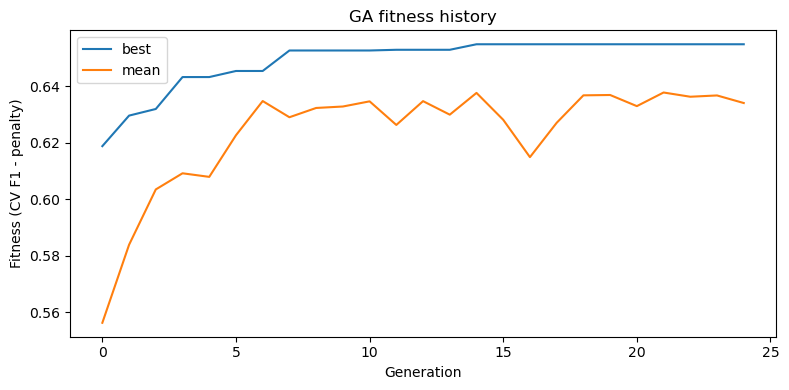

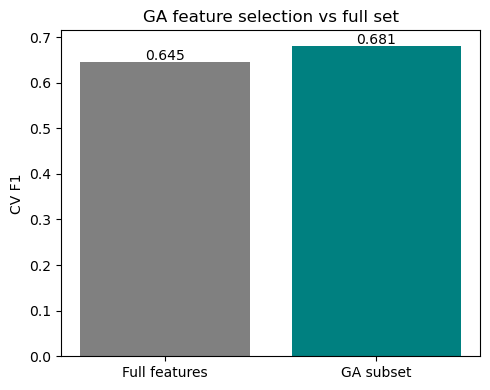

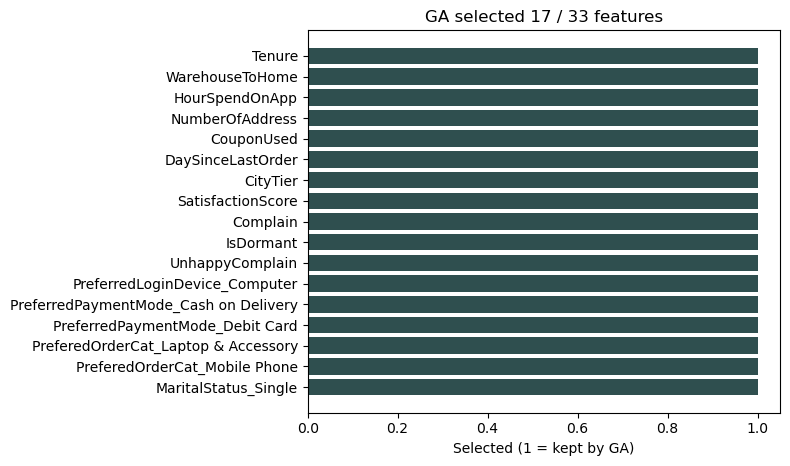

In [6]:
# Fitness history chart
plt.figure(figsize=(8, 4))
plt.plot(best_fitness_history, label="best")
plt.plot(mean_fitness_history, label="mean")
plt.xlabel("Generation")
plt.ylabel("Fitness (CV F1 - penalty)")
plt.title("GA fitness history")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/5_ga_fitness_history.png", dpi=150)
plt.show()

# Full vs GA F1
plt.figure(figsize=(5, 4))
plt.bar(["Full features", "GA subset"], [f1_full, f1_ga], color=["gray", "teal"])
plt.ylabel("CV F1")
plt.title("GA feature selection vs full set")
plt.text(0, f1_full + 0.005, str(round(f1_full, 3)), ha="center")
plt.text(1, f1_ga + 0.005, str(round(f1_ga, 3)), ha="center")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/5_ga_f1_compare.png", dpi=150)
plt.show()

# Which features were kept
plt.figure(figsize=(8, max(3, 0.28 * len(selected_features))))
plt.barh(selected_features[::-1], [1] * len(selected_features), color="darkslategray")
plt.xlabel("Selected (1 = kept by GA)")
plt.title("GA selected " + str(len(selected_features)) + " / " + str(n_features) + " features")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/5_ga_selected_features.png", dpi=150)
plt.show()

## How to read the charts

- **Fitness history:** best fitness should rise or stay high over generations.
  Mean fitness usually rises too as the population improves.
- **Full vs GA F1:** if the green bar is close to (or better than) the grey bar
  while using fewer features, GA succeeded.
- **Selected features list:** these are the bits set to 1 in the best chromosome.

## Conclusion of notebook 5

We implemented a binary GA from scratch and used it to shrink the feature set
for churn prediction.

**Files created**

- `data/clean/ga_feature_selection.json`
- `data/clean/ga_selected_features.csv`
- `figures/5_ga_fitness_history.png`
- `figures/5_ga_f1_compare.png`
- `figures/5_ga_selected_features.png`

We skipped PCA because GA already performs feature reduction while
keeping interpretable column names for TabNet and the business playbook.

**Next:** notebook 6 runs Particle Swarm Optimization and compares GA vs PSO.